In [14]:
import pandas as pd 
import numpy as np
import random

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

from tensorflow.keras.optimizers import Adam

import os

import joblib

datos_entrenamiento = "../data/gold/dataset_entrenamiento.csv"

df_entrenamiento = pd.read_csv(datos_entrenamiento)

x = df_entrenamiento.drop(columns = ["derroche_hora_siguiente"])
y = df_entrenamiento["derroche_hora_siguiente"]

In [15]:
# Aplicar Seno y Coseno
def transformacion_ciclica(df, columna, max_valor):
    df[columna + '_sin'] = np.sin(2 * np.pi * df[columna] / max_valor)
    df[columna + '_cos'] = np.cos(2 * np.pi * df[columna] / max_valor)
    return df.drop(columns=[columna])

x = transformacion_ciclica(x, 'mes', 12)
x = transformacion_ciclica(x, 'dia_de_la_semana', 7)
x = transformacion_ciclica(x, 'hora', 24)
x = transformacion_ciclica(x, 'mislata_viento_dir', 360)
x = transformacion_ciclica(x, 'sol_azimut', 360)

In [16]:
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

In [17]:
# Estandarizamos
scaler = StandardScaler()

x_train_scaled = scaler.fit_transform(x_train)

x_test_scaled = scaler.transform(x_test)

joblib.dump(scaler, '../models/scaler.pkl')
joblib.dump(x.columns.tolist(), '../models/orden_columnas.pkl')

['../models/orden_columnas.pkl']

In [18]:
def compile_model(capas, activacion, epochs, metrics, optimizer='adam', pesos=None, callbacks=None):
    random.seed(5)
    np.random.seed(5)
    tf.random.set_seed(5)
    
    model = Sequential()
    
    for i, neurons in enumerate(capas[:-1]):
        if i == 0:
            model.add(Dense(neurons, input_dim=x.shape[1], activation=activacion))
        else:
            model.add(Dense(neurons, activation=activacion))
    
    model.add(Dense(capas[-1], activation="sigmoid"))
    
    model.compile(optimizer=optimizer,loss='binary_crossentropy', metrics = metrics)

    history = model.fit(x_train_scaled,y_train,validation_data=(x_test_scaled,y_test),epochs=epochs,verbose=False, class_weight=pesos, callbacks=callbacks)
    
    return model, history

/home/david/miniconda3/envs/iabd/lib/python3.10/site-packages/keras/src/layers/core/dense.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


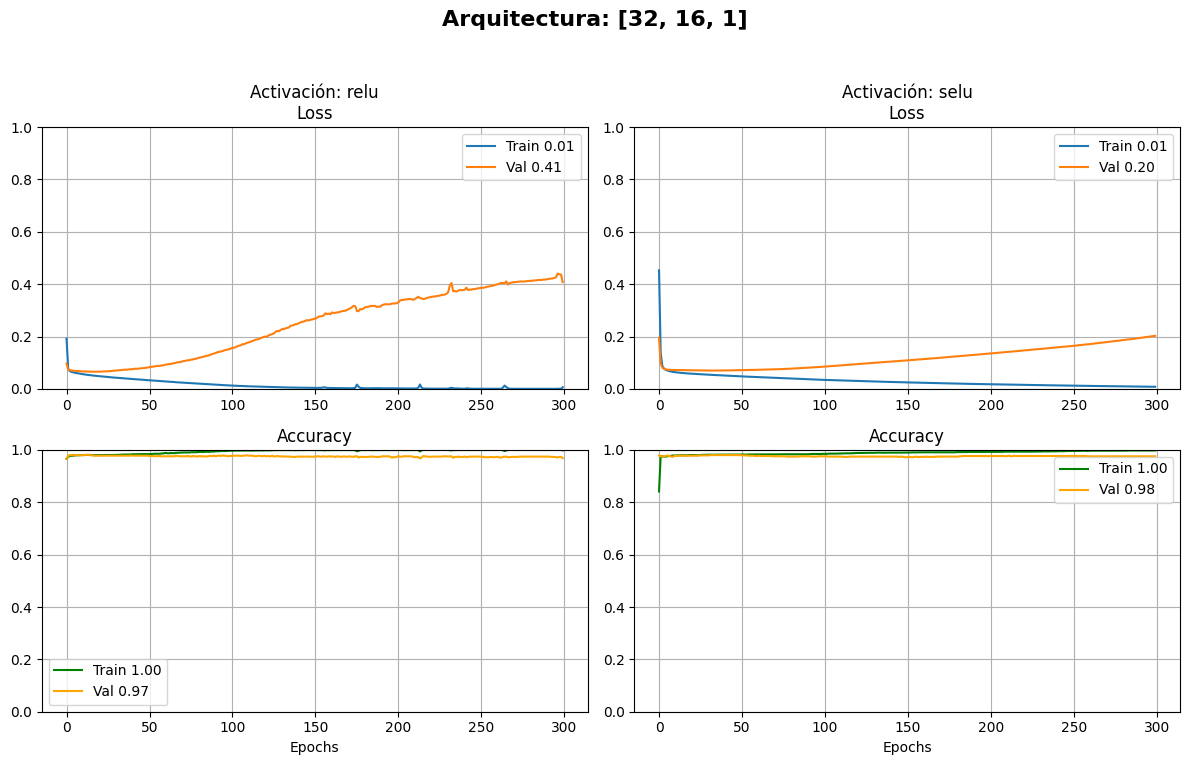

In [19]:
redes = [
    [[32, 16, 1],"relu", 300],
    [[32, 16, 1],"selu", 300],
]

capas_base = redes[0][0]
fig, axs = plt.subplots(2, 2, figsize=(12, 8))
fig.suptitle(f'Arquitectura: {capas_base}', fontsize=16, fontweight='bold')

columna = 0

metricas = ['accuracy']

for capas, activacion, epocas in redes:
    
    model, history = compile_model(capas, activacion, epocas, metricas)

    axs[0, columna].plot(history.history['loss'], label=f"Train {history.history['loss'][-1]:.2f}")
    axs[0, columna].plot(history.history['val_loss'], label=f"Val {history.history['val_loss'][-1]:.2f}")
    axs[0, columna].set_title(f'Activación: {activacion}\nLoss')
    axs[0, columna].set_ylim(0, 1)
    axs[0, columna].legend()
    axs[0, columna].grid(True)

    axs[1, columna].plot(history.history['accuracy'], label= f"Train {history.history['accuracy'][-1]:.2f}", color='green')
    axs[1, columna].plot(history.history['val_accuracy'], label=f"Val {history.history['val_accuracy'][-1]:.2f}", color='orange')
    axs[1, columna].set_title(f'Accuracy') 
    axs[1, columna].set_xlabel('Epochs')
    axs[1, columna].set_ylim(0, 1)
    axs[1, columna].legend()
    axs[1, columna].grid(True)

    columna += 1

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

# Class Weights


Epoch 1: val_auc_pr improved from None to 0.05045, saving model to ../models/modelo_32_16_1_relu.keras

Epoch 2: val_auc_pr improved from 0.05045 to 0.21217, saving model to ../models/modelo_32_16_1_relu.keras

Epoch 3: val_auc_pr improved from 0.21217 to 0.41409, saving model to ../models/modelo_32_16_1_relu.keras

Epoch 4: val_auc_pr improved from 0.41409 to 0.58417, saving model to ../models/modelo_32_16_1_relu.keras

Epoch 5: val_auc_pr improved from 0.58417 to 0.65202, saving model to ../models/modelo_32_16_1_relu.keras

Epoch 6: val_auc_pr improved from 0.65202 to 0.68701, saving model to ../models/modelo_32_16_1_relu.keras

Epoch 7: val_auc_pr improved from 0.68701 to 0.70420, saving model to ../models/modelo_32_16_1_relu.keras

Epoch 8: val_auc_pr improved from 0.70420 to 0.71501, saving model to ../models/modelo_32_16_1_relu.keras

Epoch 9: val_auc_pr improved from 0.71501 to 0.72148, saving model to ../models/modelo_32_16_1_relu.keras

Epoch 10: val_auc_pr improved from 0.72

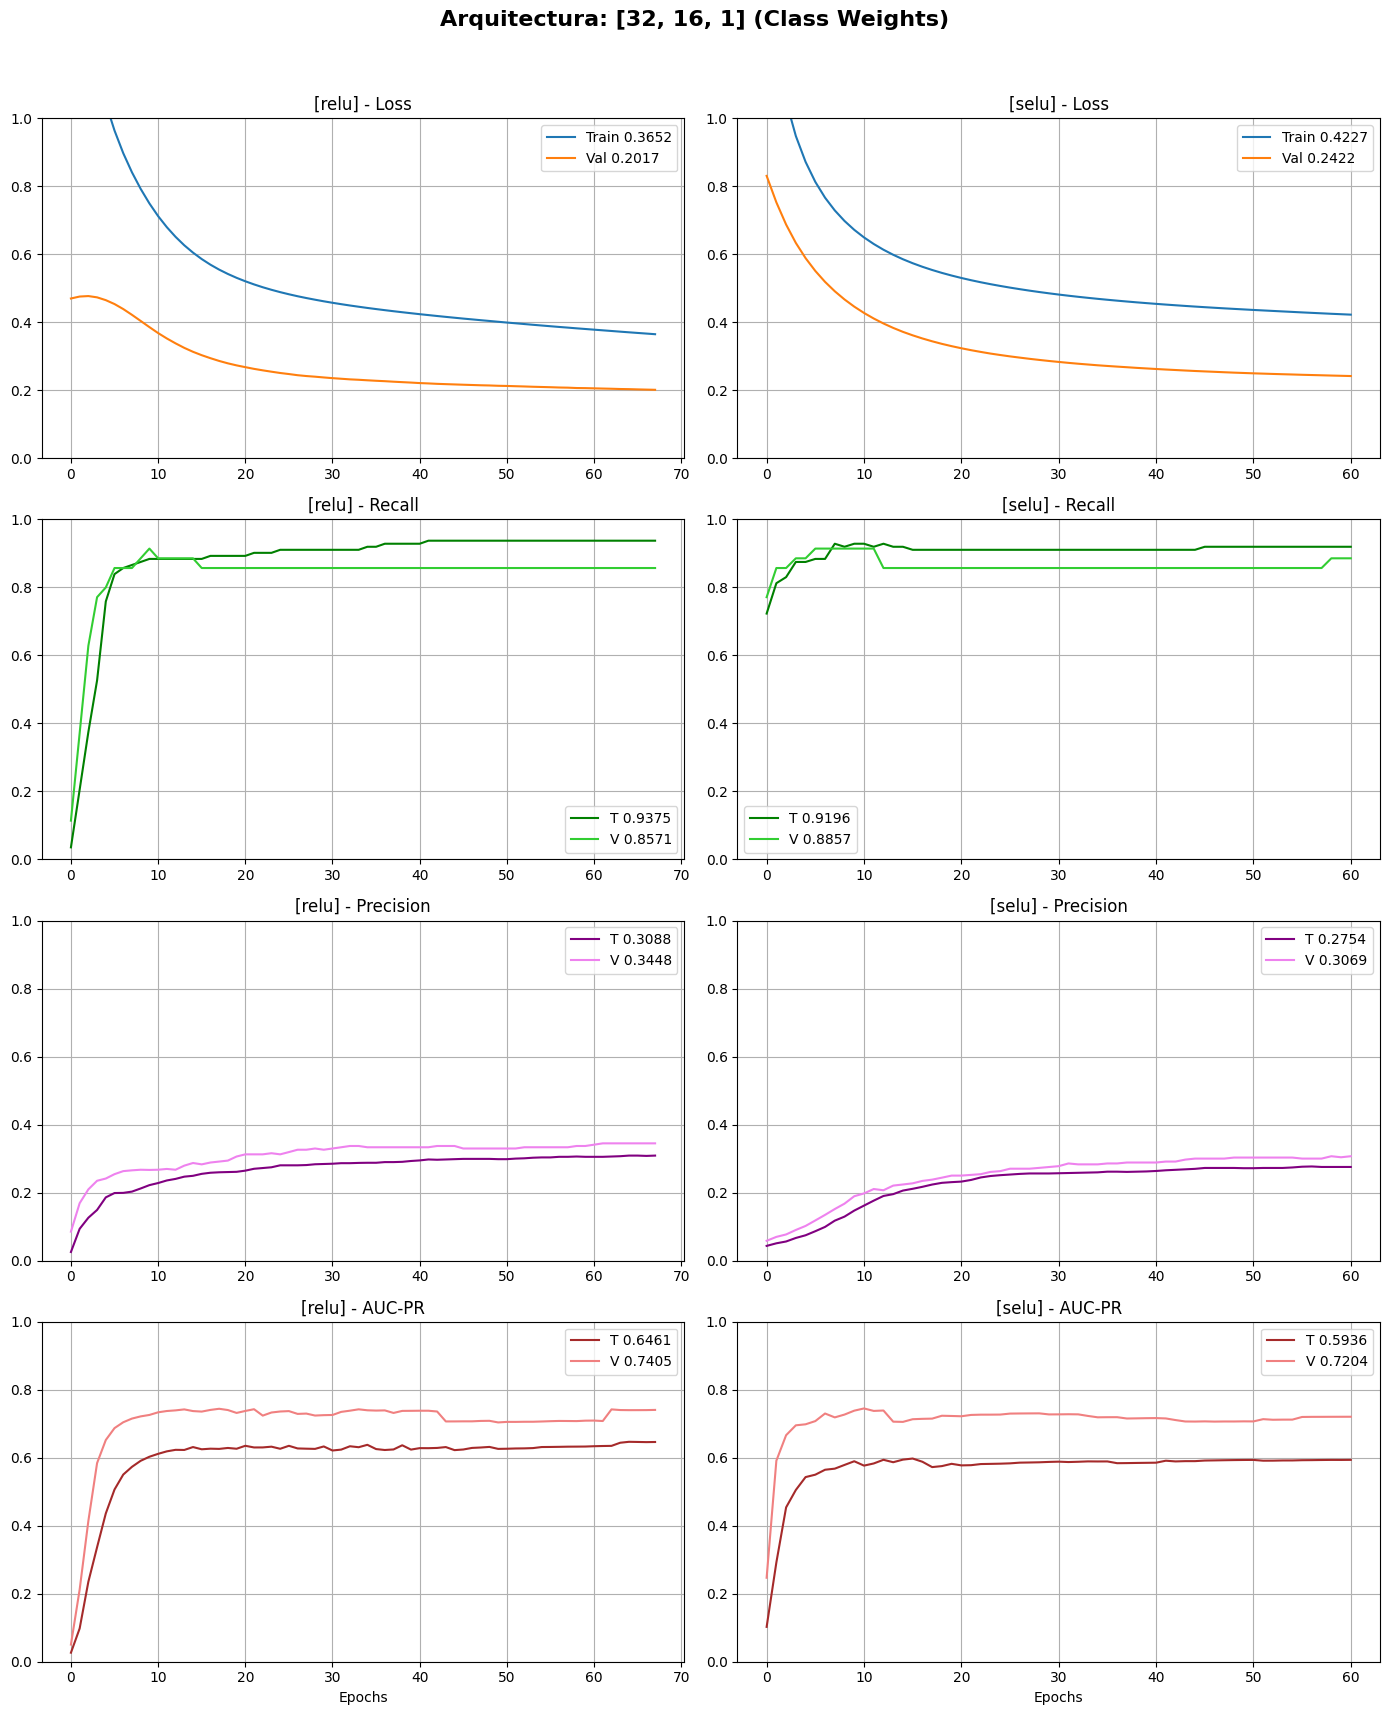


Epoch 1: val_auc_pr improved from None to 0.74148, saving model to ../models/modelo_128_64_32_1_relu.keras

Epoch 2: val_auc_pr improved from 0.74148 to 0.76722, saving model to ../models/modelo_128_64_32_1_relu.keras

Epoch 3: val_auc_pr did not improve from 0.76722

Epoch 4: val_auc_pr did not improve from 0.76722

Epoch 5: val_auc_pr did not improve from 0.76722

Epoch 6: val_auc_pr did not improve from 0.76722

Epoch 7: val_auc_pr did not improve from 0.76722

Epoch 8: val_auc_pr did not improve from 0.76722

Epoch 9: val_auc_pr did not improve from 0.76722

Epoch 10: val_auc_pr did not improve from 0.76722

Epoch 11: val_auc_pr did not improve from 0.76722

Epoch 12: val_auc_pr did not improve from 0.76722

Epoch 13: val_auc_pr did not improve from 0.76722

Epoch 14: val_auc_pr did not improve from 0.76722

Epoch 15: val_auc_pr did not improve from 0.76722

Epoch 16: val_auc_pr did not improve from 0.76722

Epoch 17: val_auc_pr did not improve from 0.76722

Epoch 18: val_auc_pr d

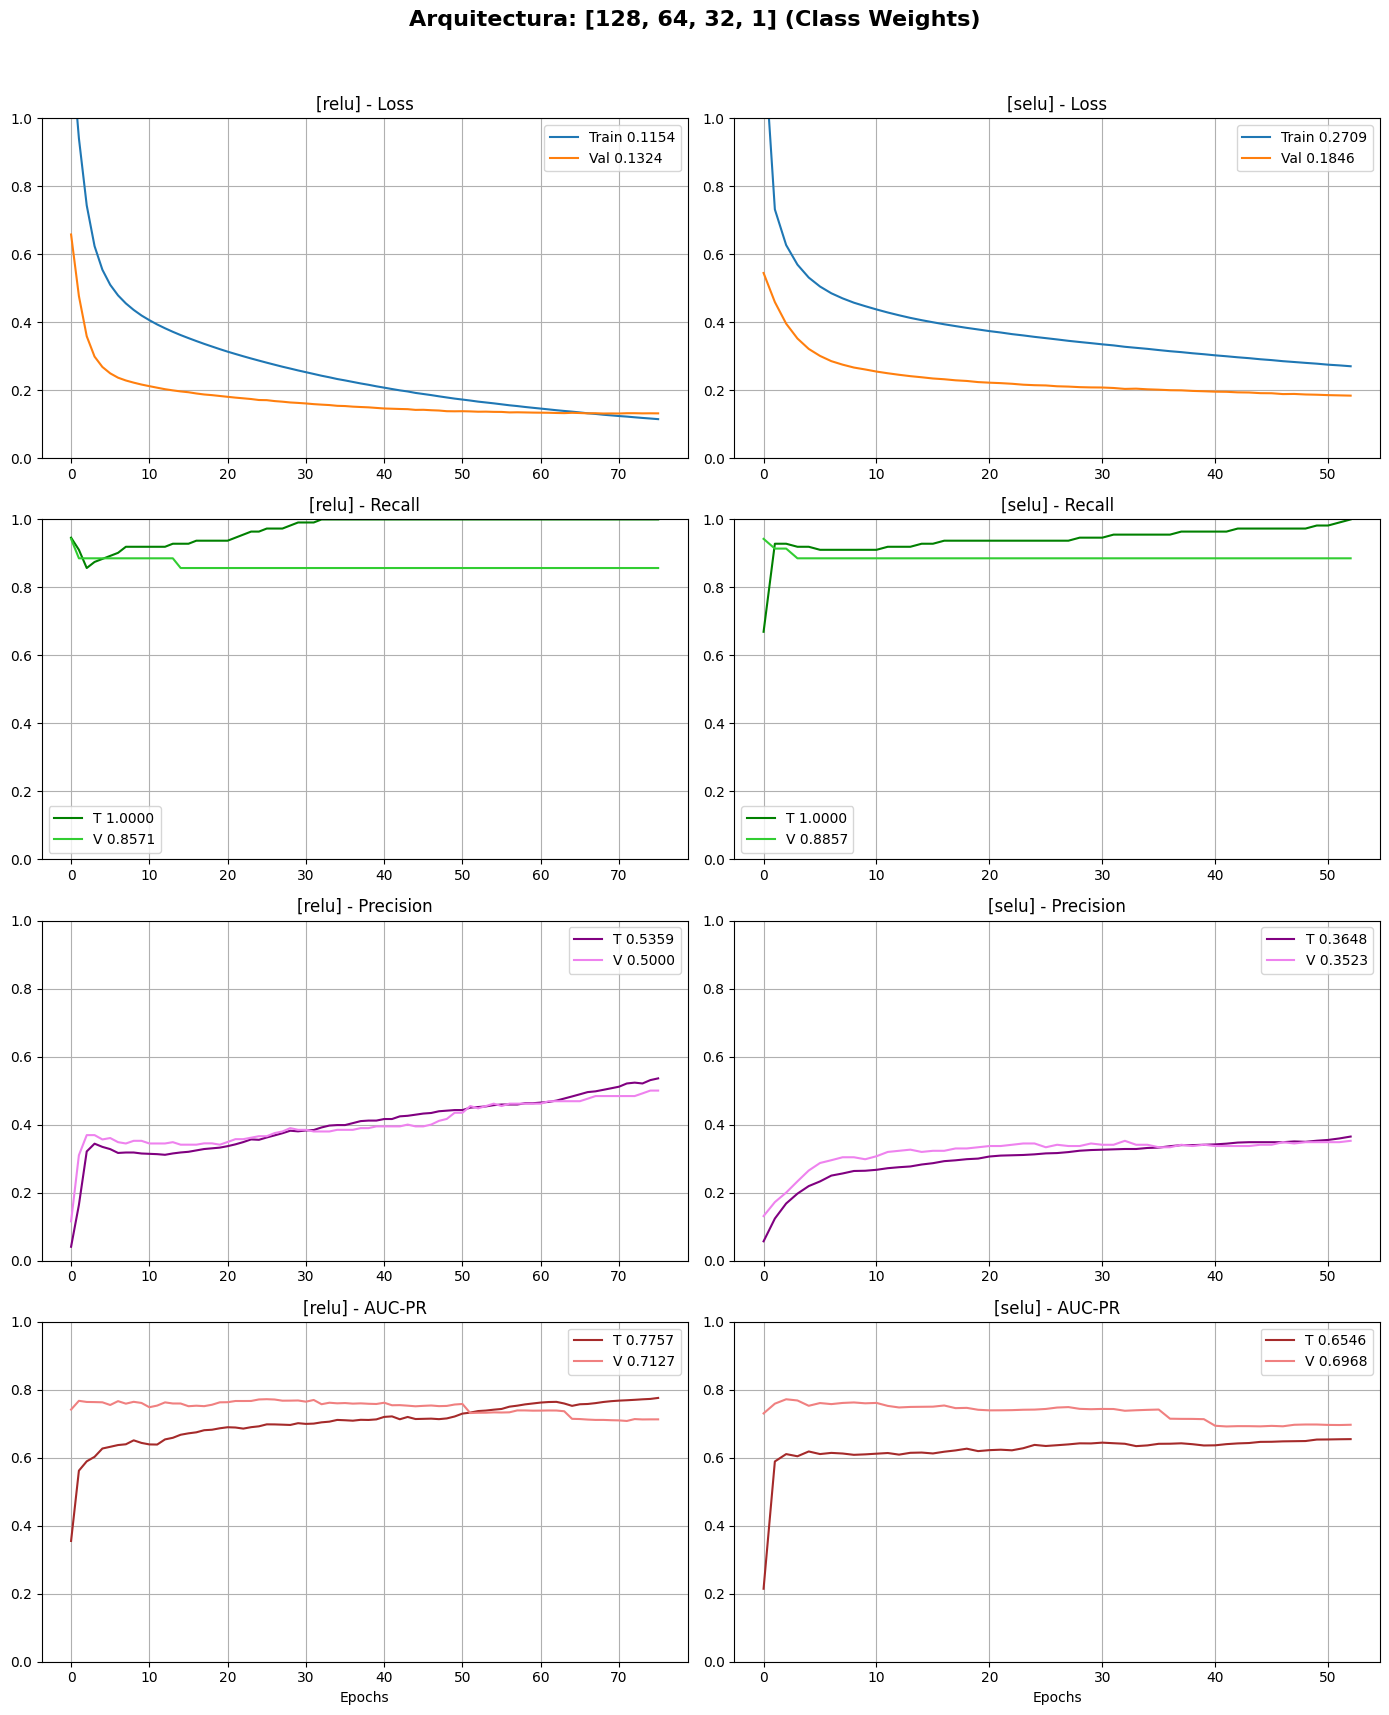


Epoch 1: val_auc_pr improved from None to 0.72237, saving model to ../models/modelo_256_128_64_32_1_relu.keras

Epoch 2: val_auc_pr improved from 0.72237 to 0.74279, saving model to ../models/modelo_256_128_64_32_1_relu.keras

Epoch 3: val_auc_pr improved from 0.74279 to 0.75361, saving model to ../models/modelo_256_128_64_32_1_relu.keras

Epoch 4: val_auc_pr did not improve from 0.75361

Epoch 5: val_auc_pr did not improve from 0.75361

Epoch 6: val_auc_pr improved from 0.75361 to 0.75506, saving model to ../models/modelo_256_128_64_32_1_relu.keras

Epoch 7: val_auc_pr improved from 0.75506 to 0.76344, saving model to ../models/modelo_256_128_64_32_1_relu.keras

Epoch 8: val_auc_pr did not improve from 0.76344

Epoch 9: val_auc_pr did not improve from 0.76344

Epoch 10: val_auc_pr did not improve from 0.76344

Epoch 11: val_auc_pr did not improve from 0.76344

Epoch 12: val_auc_pr did not improve from 0.76344

Epoch 13: val_auc_pr did not improve from 0.76344

Epoch 14: val_auc_pr di

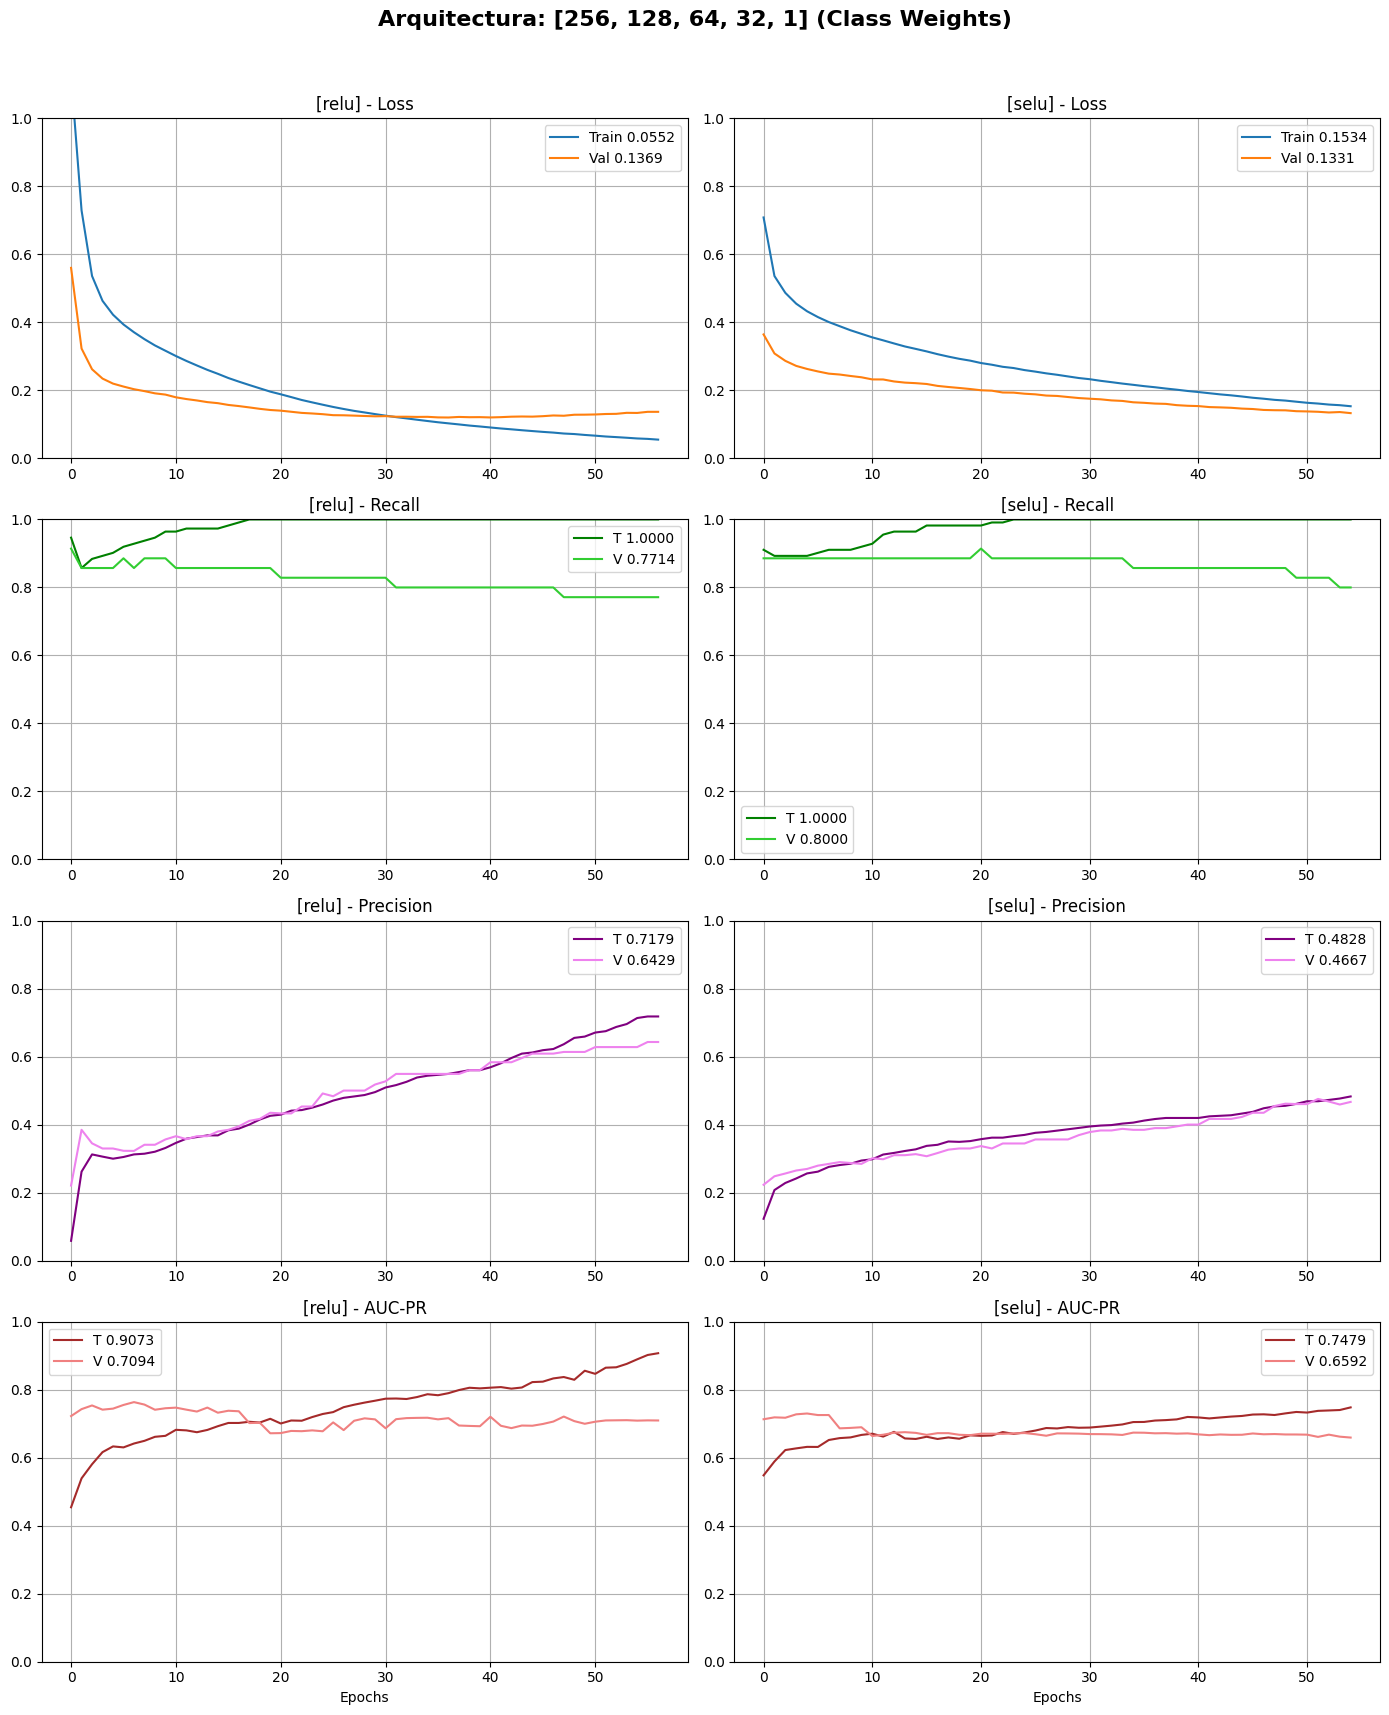

In [20]:
redes = [
    [[32, 16, 1], "relu", 1000],
    [[32, 16, 1], "selu", 1000],
    [[128, 64, 32, 1], "relu", 1000],
    [[128, 64, 32, 1], "selu", 1000],
    [[256, 128, 64, 32, 1], "relu", 1000], 
    [[256, 128, 64, 32, 1], "selu", 1000]
]

pesos = {
    0: 1.0, 
    1: 32.0
}

path = "../models"

columna = 0

for capas, activacion, epocas in redes:

    if columna == 0:
        fig, axs = plt.subplots(4, 2, figsize=(14, 18))
        fig.suptitle(f'Arquitectura: {capas} (Class Weights)', fontsize=16, fontweight='bold')

    metricas = [
    tf.keras.metrics.Recall(name='recall'),
    tf.keras.metrics.Precision(name='precision'),
    tf.keras.metrics.AUC(name='auc_pr', curve='PR')
    ]

    opt = Adam(learning_rate=0.0001)

    str_capas = '_'.join(map(str, capas))
    nombre_archivo = f"modelo_{str_capas}_{activacion}.keras"
    ruta_completa = os.path.join(path, nombre_archivo)

    early_stop = EarlyStopping(monitor='val_auc_pr', mode='max', patience=50, restore_best_weights=True)

    checkpoint = ModelCheckpoint(
        filepath=ruta_completa,
        monitor='val_auc_pr',
        mode='max',
        save_best_only=True,
        verbose=1
    )
    
    model, history = compile_model(
        capas, 
        activacion, 
        epocas, 
        metrics=metricas, 
        pesos=pesos,
        callbacks=[early_stop, checkpoint],
        optimizer=opt
    )

    # Loss
    axs[0, columna].plot(history.history['loss'], label=f"Train {history.history['loss'][-1]:.4f}")
    axs[0, columna].plot(history.history['val_loss'], label=f"Val {history.history['val_loss'][-1]:.4f}")
    axs[0, columna].set_title(f'[{activacion}] - Loss')
    axs[0, columna].set_ylim(0, 1)
    axs[0, columna].legend(); axs[0, columna].grid(True)

    # Recall
    axs[1, columna].plot(history.history['recall'], label=f"T {history.history['recall'][-1]:.4f}", color='green')
    axs[1, columna].plot(history.history['val_recall'], label=f"V {history.history['val_recall'][-1]:.4f}", color='limegreen')
    axs[1, columna].set_title(f'[{activacion}] - Recall'); axs[1, columna].set_ylim(0, 1)
    axs[1, columna].legend(); axs[1, columna].grid(True)

    # Precision
    axs[2, columna].plot(history.history['precision'], label=f"T {history.history['precision'][-1]:.4f}", color='purple')
    axs[2, columna].plot(history.history['val_precision'], label=f"V {history.history['val_precision'][-1]:.4f}", color='violet')
    axs[2, columna].set_title(f'[{activacion}] - Precision'); axs[2, columna].set_ylim(0, 1)
    axs[2, columna].legend(); axs[2, columna].grid(True)

    # AUC-PR
    axs[3, columna].plot(history.history['auc_pr'], label=f"T {history.history['auc_pr'][-1]:.4f}", color='brown')
    axs[3, columna].plot(history.history['val_auc_pr'], label=f"V {history.history['val_auc_pr'][-1]:.4f}", color='lightcoral')
    axs[3, columna].set_title(f'[{activacion}] - AUC-PR'); axs[3, columna].set_xlabel('Epochs'); axs[3, columna].set_ylim(0, 1)
    axs[3, columna].legend(); axs[3, columna].grid(True)

    columna += 1

    if columna == 2:
        plt.tight_layout(rect=[0, 0.03, 1, 0.96])
        plt.show()
        columna = 0

# Nos quedamos con la arquitectura [128, 64, 32, 1] [relu]